
# K-Means on Nonlinear Dataset

## Objective
Understand the limitation of K-Means clustering on nonlinear data.

## Dataset
`kmeans_nonlinear.csv`

## Tasks
- Apply K-Means with:
  - K = 2
  - K = 3
- Plot clusters

## Questions
1. Does K-Means correctly identify the natural clusters?
2. What is unusual about the shape of the data?
3. What assumption of K-Means is violated here?


In [1]:

# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

print("Libraries imported successfully")


Libraries imported successfully


In [2]:

# Load dataset

data = pd.read_csv("kmeans_nonlinear.csv")

print("First 5 rows of dataset")
display(data.head())

print("\nDataset shape:", data.shape)


First 5 rows of dataset


,Feature1,Feature2
0,0.682988,-0.345203
1,2.040990,-0.131615
2,-0.139752,0.454391
3,0.885748,0.286342
4,1.182459,-0.497711



Dataset shape: (300, 2)


In [3]:

# Dataset information

print("Dataset Info")
print(data.info())

print("\nStatistical Summary")
display(data.describe())


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  300 non-null    float64
 1   Feature2  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB
None

Statistical Summary


,Feature1,Feature2
count,300.000000,300.000000
mean,0.500825,0.256391
std,0.876485,0.503362
min,-1.227276,-0.672842
25%,-0.094171,-0.184390
50%,0.461503,0.258601
75%,1.096026,0.709077
max,2.270386,1.239951



# Step 1: Select Features

We assume all columns are numerical input features.


In [4]:

# Select features

X = data.copy()

print("Feature matrix shape:", X.shape)

display(X.head())


Feature matrix shape: (300, 2)


,Feature1,Feature2
0,0.682988,-0.345203
1,2.040990,-0.131615
2,-0.139752,0.454391
3,0.885748,0.286342
4,1.182459,-0.497711



# Visualize Original Dataset


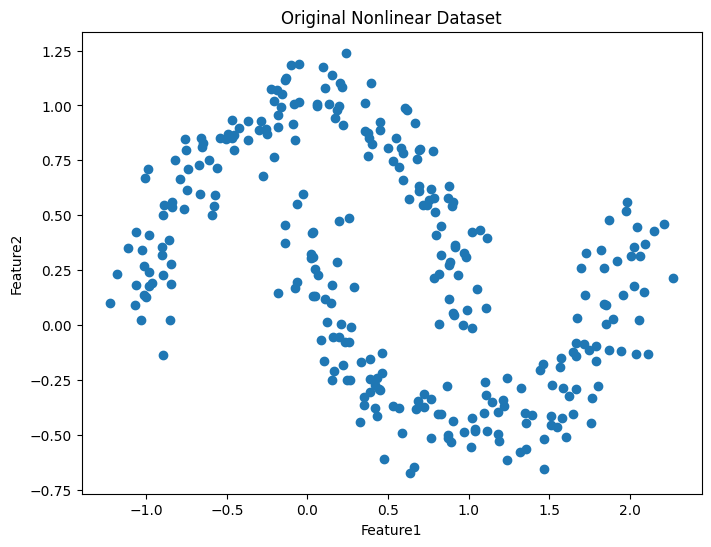

In [5]:

# Plot original data

plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1]
)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("Original Nonlinear Dataset")

plt.show()



# K-Means with K = 2


In [6]:

# Apply K-Means with K=2

kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters_2 = kmeans_2.fit_predict(X)

centroids_2 = kmeans_2.cluster_centers_

print("Cluster labels for K=2")
print(clusters_2[:20])

print("\nCentroids for K=2")
print(centroids_2)


Cluster labels for K=2
[0 0 1 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 1]

Centroids for K=2
[[ 1.20327757 -0.07141764]
 [-0.20162688  0.58420052]]


C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


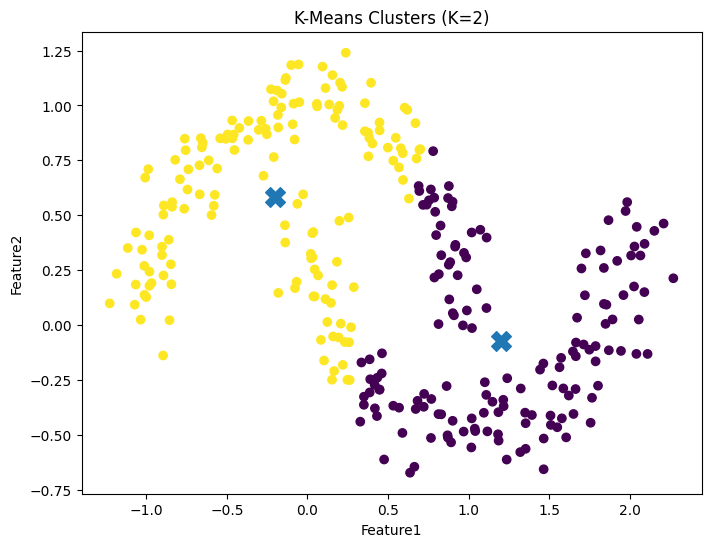

In [7]:

# Plot K=2 clusters

plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=clusters_2
)

plt.scatter(
    centroids_2[:,0],
    centroids_2[:,1],
    marker='X',
    s=200
)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("K-Means Clusters (K=2)")

plt.show()



# K-Means with K = 3


In [8]:

# Apply K-Means with K=3

kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_3 = kmeans_3.fit_predict(X)

centroids_3 = kmeans_3.cluster_centers_

print("Cluster labels for K=3")
print(clusters_3[:20])

print("\nCentroids for K=3")
print(centroids_3)


Cluster labels for K=3
[1 2 0 1 2 2 1 0 1 1 2 1 2 1 1 2 2 1 0 1]

Centroids for K=3
[[-0.48934361  0.68662126]
 [ 0.54129737  0.18251156]
 [ 1.61341345 -0.13906915]]


C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


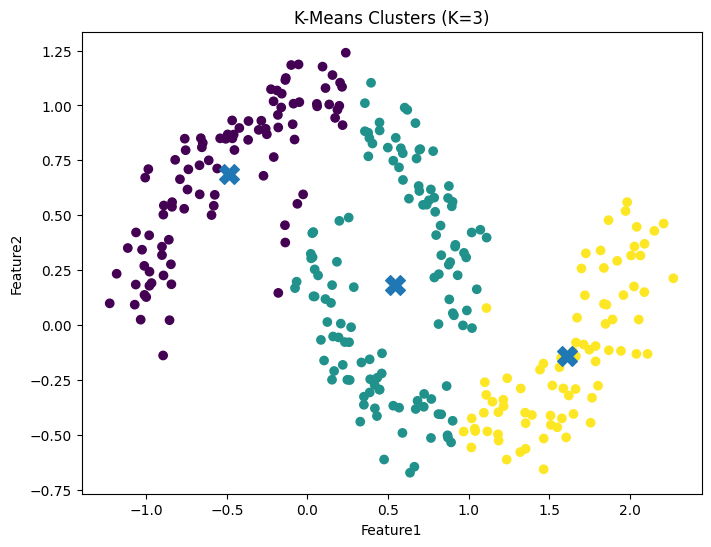

In [9]:

# Plot K=3 clusters

plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=clusters_3
)

plt.scatter(
    centroids_3[:,0],
    centroids_3[:,1],
    marker='X',
    s=200
)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("K-Means Clusters (K=3)")

plt.show()



# Understanding the Limitation of K-Means

K-Means works best when:
- Clusters are spherical
- Clusters are compact
- Clusters are linearly separable

However, nonlinear datasets may contain:
- Circular shapes
- Spiral patterns
- Moon-shaped clusters
- Nested clusters

K-Means struggles because it separates data using distance to centroids.



# Mathematical Assumption of K-Means

K-Means minimizes:

WCSS = Sum of squared distance between points and centroid

It assumes:
- Euclidean distance works correctly
- Clusters are convex and spherical
- Each cluster has similar spread

Nonlinear datasets violate these assumptions.



# Answers to Questions

## 1. Does K-Means correctly identify the natural clusters?
- Usually no.
- K-Means may split nonlinear clusters incorrectly.
- Points from the same natural cluster may be assigned to different clusters.

---

## 2. What is unusual about the shape of the data?
- The dataset likely contains nonlinear shapes such as:
  - Curved patterns
  - Circular structures
  - Spiral or moon-shaped clusters
- These shapes are not spherical.

---

## 3. What assumption of K-Means is violated here?
- K-Means assumes clusters are:
  - Spherical
  - Convex
  - Linearly separable
- Nonlinear data violates this assumption.
- Euclidean centroid-based separation becomes ineffective.
